# 02 — Modelagem Supervisionada
## Pipeline de ML, validação e otimização

**Protocolo (justificado na EDA):**

1. **Split temporal como avaliação principal:** treino = 2023, teste = 2024.
   É o cenário real de uso (prever a próxima edição da avaliação) e a prova mais
   honesta de generalização.
2. **Validação cruzada agrupada por município** (`StratifiedGroupKFold`) dentro
   de 2023 para comparar candidatos e otimizar hiperparâmetros: alunos do mesmo
   município nunca ficam em treino e validação ao mesmo tempo (sem isso o modelo
   "decora" o território e a métrica infla).
3. Comparação e busca de hiperparâmetros numa **subamostra agrupada de ~400 mil
   alunos** (municípios inteiros; limite de memória da máquina de 8 GB); o
   campeão é re-treinado na base completa de 2023.
4. **Replicabilidade:** semente fixa (42) em tudo; ambiente em `requirements.txt`.

O código executável está em `src/preprocessing/pipeline.py` e
`src/modeling/train.py` (rodado por `python -m src.modeling.train`); este
notebook demonstra a pipeline e analisa os resultados.

In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "..")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../images")

with open("../reports/metricas_modelagem.json") as f:
    res = json.load(f)

## 1. A pipeline (pré-processamento integrado ao modelo)

Toda transformação vive dentro do `Pipeline` do sklearn. Consequência prática:
em **qualquer** `fit` (cada fold da validação cruzada, cada candidato da busca,
o treino final), imputação, escala e encoding são ajustados **apenas no treino
daquele fit** — o vazamento clássico de "ajustar o scaler na base inteira" fica
impossível por construção.

- **Numéricas (31):** imputação pela **mediana** (robusta às caudas longas de
  população, PIB e renda) + padronização quando o estimador precisa (linear);
- **Categóricas (3: rede, região, UF):** One-Hot Encoding com
  `handle_unknown="ignore"`;
- **Alvo:** `alfabetizado`; **chaves** (`ano`, `id_municipio`, `id_escola`) e
  `peso_aluno` ficam fora das features.

In [2]:
from sklearn import set_config
from src.preprocessing.pipeline import make_pipeline
from lightgbm import LGBMClassifier

set_config(display="diagram")
make_pipeline(LGBMClassifier())   # visualização da estrutura da pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{tran

## 2. Comparação de modelos (CV agrupada, ROC-AUC)

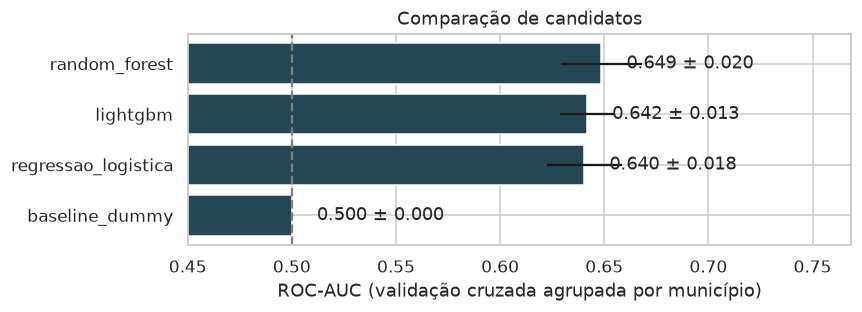

,roc_auc_cv,desvio
baseline_dummy,0.5000,0.0000
regressao_logistica,0.6405,0.0182
lightgbm,0.6418,0.0130
random_forest,0.6486,0.0196


In [3]:
cmp = pd.DataFrame(res["comparacao_cv"]).T.sort_values("roc_auc_cv")
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(cmp.index, cmp["roc_auc_cv"], xerr=cmp["desvio"], color="#264653")
ax.axvline(0.5, ls="--", color="gray")
ax.set_xlabel("ROC-AUC (validação cruzada agrupada por município)")
ax.set_title("Comparação de candidatos")
for i, (v, s) in enumerate(zip(cmp["roc_auc_cv"], cmp["desvio"])):
    ax.text(v + 0.012, i, f"{v:.3f} ± {s:.3f}", va="center")
ax.set_xlim(0.45, cmp["roc_auc_cv"].max() + 0.12)
plt.tight_layout()
plt.savefig(IMG / "mod_comparacao.png", bbox_inches="tight")
plt.show()
cmp.round(4)

## 3. Otimização do campeão (LightGBM)

`RandomizedSearchCV` (12 combinações × 3 folds agrupados) sobre número de
árvores, taxa de aprendizado, folhas, amostragem de linhas/colunas e
regularização L2 — alavancas diretas contra overfitting.

In [4]:
print(f"Melhor ROC-AUC na CV: {res['tuning']['best_score_cv']:.4f}")
pd.Series(res["tuning"]["best_params"]).rename("melhor valor").to_frame()

Melhor ROC-AUC na CV: 0.6538


,melhor valor
model__subsample,0.85
model__reg_lambda,5.00
model__num_leaves,31.00
model__n_estimators,400.00
model__min_child_samples,20.00
model__learning_rate,0.05
model__colsample_bytree,0.70


## 4. Avaliação final — validação temporal (treina 2023 → testa 2024)

Métricas **simples** e **ponderadas pelo peso amostral** (a visão ponderada é a
representativa da população de alunos).

In [5]:
aval = res["avaliacao_temporal_2024"]
tab = pd.concat({
    "treino 2023 (simples)": pd.Series(aval["treino_2023"]["simples"]),
    "teste 2024 (simples)": pd.Series(aval["teste_2024"]["simples"]),
    "teste 2024 (ponderada)": pd.Series(aval["teste_2024"]["ponderada_peso_amostral"]),
}, axis=1)
tab.round(4)

,treino 2023 (simples),teste 2024 (simples),teste 2024 (ponderada)
roc_auc,0.6876,0.6398,0.6372
accuracy,0.6457,0.6310,0.6258
balanced_accuracy,0.6110,0.5711,0.5690
f1,0.7294,0.7399,0.7352
precision,0.6581,0.6392,0.6326
recall,0.8181,0.8783,0.8777
brier,0.2174,0.2261,0.2277


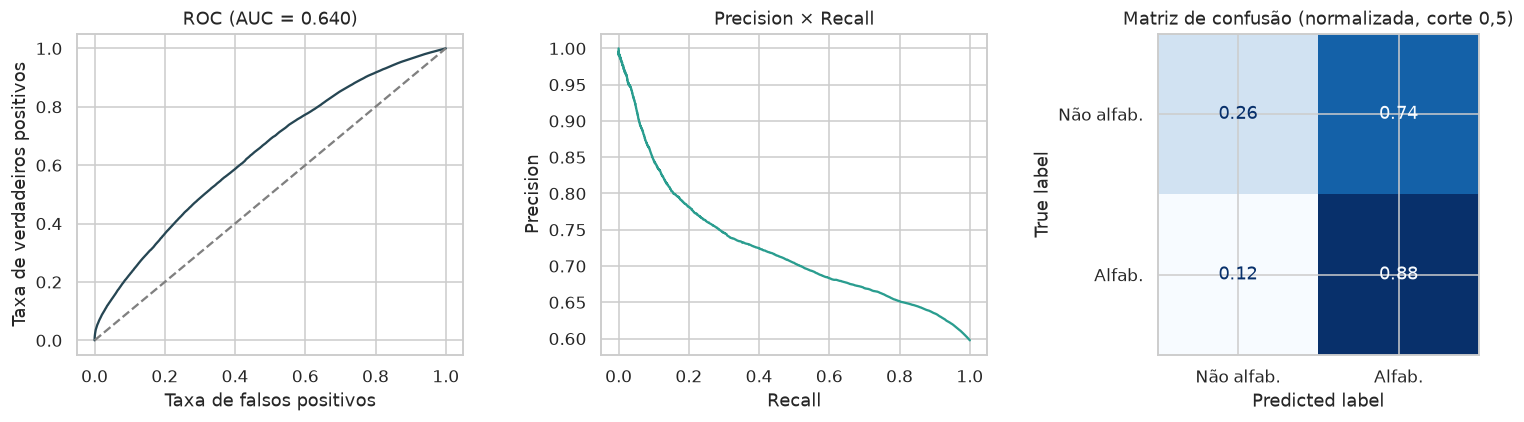

In [6]:
from sklearn.metrics import (roc_curve, precision_recall_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
pred = pd.read_parquet("../data/predicoes_teste_2024.parquet")
y, p = pred["alfabetizado"].astype(int), pred["prob_alfabetizado"]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
fpr, tpr, _ = roc_curve(y, p)
ax[0].plot(fpr, tpr, color="#264653")
ax[0].plot([0, 1], [0, 1], ls="--", color="gray")
ax[0].set_title(f"ROC (AUC = {aval['teste_2024']['simples']['roc_auc']:.3f})")
ax[0].set_xlabel("Taxa de falsos positivos"); ax[0].set_ylabel("Taxa de verdadeiros positivos")

prec, rec, _ = precision_recall_curve(y, p)
ax[1].plot(rec, prec, color="#2a9d8f")
ax[1].set_title("Precision × Recall")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")

cm = confusion_matrix(y, (p >= 0.5).astype(int), normalize="true")
ConfusionMatrixDisplay(cm, display_labels=["Não alfab.", "Alfab."]).plot(
    ax=ax[2], colorbar=False, values_format=".2f", cmap="Blues")
ax[2].set_title("Matriz de confusão (normalizada, corte 0,5)")
plt.tight_layout()
plt.savefig(IMG / "mod_avaliacao.png", bbox_inches="tight")
plt.show()

In [7]:
# Sensibilidade ao corte de decisão: o gestor escolhe o trade-off.
# Para triagem de risco, recall alto da classe "não alfabetizado" importa mais
# que acurácia global (deixar de sinalizar uma criança custa mais que sinalizar demais).
linhas = []
for corte in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yhat = (p >= corte).astype(int)
    nao_alf = 1 - yhat
    real_nao = 1 - y
    recall_nao = (nao_alf & real_nao).sum() / real_nao.sum()
    prec_nao = (nao_alf & real_nao).sum() / max(nao_alf.sum(), 1)
    linhas.append({"corte": corte, "recall_nao_alfabetizado": recall_nao,
                   "precision_nao_alfabetizado": prec_nao,
                   "%_sinalizados": nao_alf.mean()})
pd.DataFrame(linhas).round(3)

,corte,recall_nao_alfabetizado,precision_nao_alfabetizado,%_sinalizados
0,0.3,0.017,0.687,0.010
1,0.4,0.128,0.648,0.079
2,0.5,0.264,0.594,0.179
3,0.6,0.540,0.509,0.427
4,0.7,0.845,0.450,0.756


## 5. Leitura dos resultados

- Na comparação sem tuning os três modelos reais empatam tecnicamente
  (AUC ≈ 0,64–0,65), com leve vantagem do Random Forest. O **LightGBM otimizado**
  assume a frente na CV (0,654) e foi escolhido também pelo critério
  operacional: treina em minutos na base completa de 1,5 mi de linhas com
  memória modesta, o que o Random Forest equivalente não faz.
- O gap treino (0,688) × teste (0,640) é o diagnóstico de overfitting: pequeno,
  contido pela regularização escolhida na busca (`reg_lambda=5`, `num_leaves=31`,
  subamostragem de linhas e colunas).
- **Teto honesto:** as features são todas **contextuais** (município, escola,
  rede, território) — a base pública não traz atributos individuais do aluno
  (NSE familiar, frequência, trajetória). Modelos de desfecho individual com
  features só de contexto têm limite natural de AUC; o valor está em **ordenar
  risco** entre alunos e territórios, não em acertar cada criança.
- A tabela de cortes mostra o modelo como instrumento de **triagem**: baixando o
  corte, a rede captura mais crianças em risco ao custo de mais sinalizações.
- Interpretabilidade (o que move as previsões) no notebook 03.